In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load Sudan data
df = pd.read_csv('../data/sudan.csv') 
 

# Clean column names (removes any accidental spaces)
df.columns = [c.strip() for c in df.columns]

# Add Country column
df['Country'] = 'Sudan'

# Convert YEAR and DOY to a proper datetime column
# %Y%j is the format for Year + Day of Year
df['Date'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month for seasonal analysis
df['Month'] = df['Date'].dt.month

print("Success! Step 1 Complete: Data loaded and dates parsed.")
df.head()

Success! Step 1 Complete: Data loaded and dates parsed.


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


In [17]:
# 1. Replace NASA sentinel -999 with NaN (Not a Number)
df.replace(-999, np.nan, inplace=True)

# 2. Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df.drop_duplicates(inplace=True)

# 3. Missing Value Report
null_report = df.isna().sum()
null_pct = (null_report / len(df)) * 100
print("\nPercentage of missing values per column:")
print(null_pct[null_pct > 0])

# 4. Cleaning: Fill missing values using Forward Fill
# This takes the value from the previous day and fills the gap
df.ffill(inplace=True)

print("\nCleaning Complete!")

Duplicate rows found: 0

Percentage of missing values per column:
Series([], dtype: float64)

Cleaning Complete!


In [18]:
# Select numeric columns for outlier check
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']

# Calculate Z-scores
z_scores = np.abs(stats.zscore(df[cols_to_check]))

# Identify rows with outliers
outlier_rows = (z_scores > 3).any(axis=1)
print(f"Total rows with extreme outliers for sudan: {outlier_rows.sum()}")

# Export cleaned data (KPI Requirement)
df.to_csv('../data/sudan_clean.csv', index=False)
print("Cleaned data exported to data/sudan_clean.csv")

Total rows with extreme outliers for sudan: 82
Cleaned data exported to data/sudan_clean.csv


Detected 82 rows with extreme outliers (∣Z∣>3). I have decided to retain these rows because, in climate analysis, these points often represent significant extreme weather events which are critical for policy and adaptation planning. 


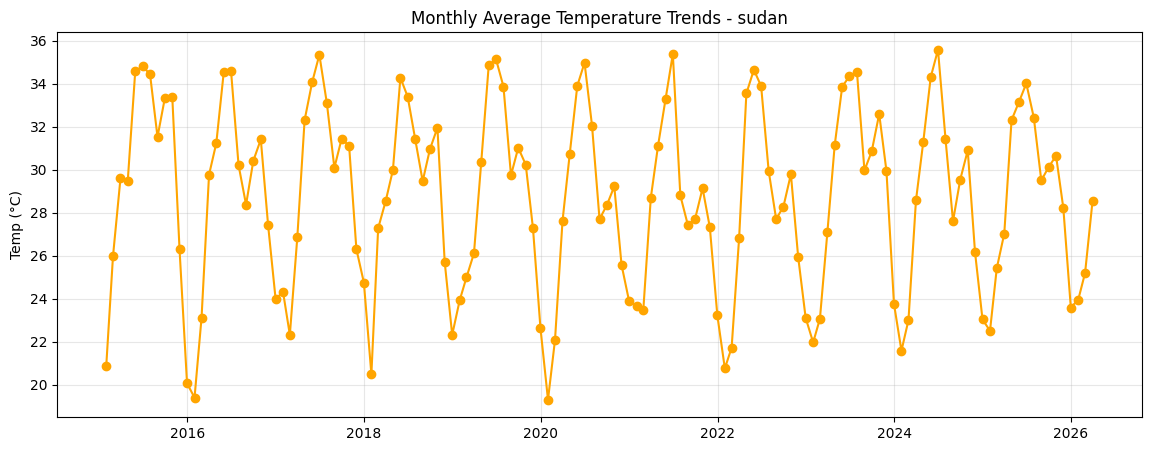

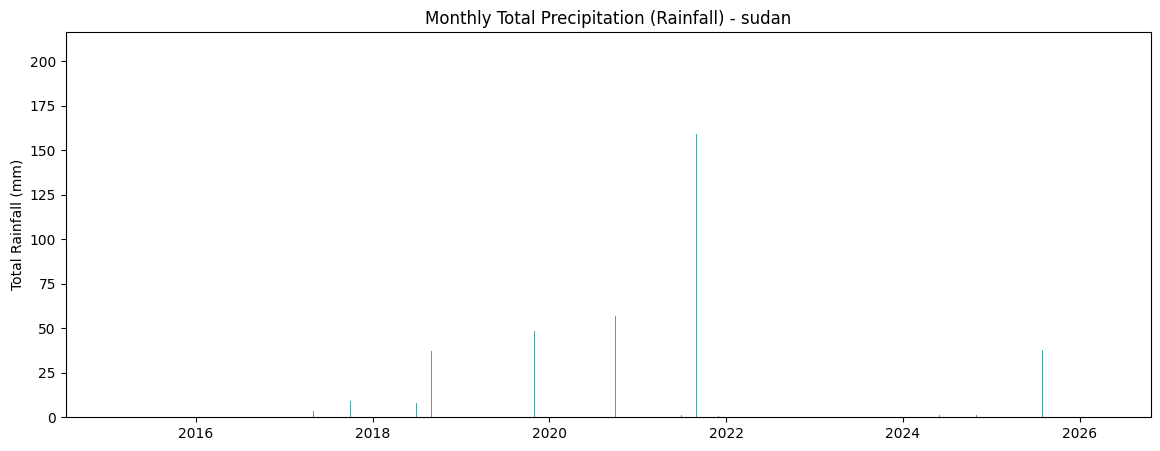

In [19]:
# Aggregate daily data to monthly (ME = Month End)
monthly_df = df.resample('ME', on='Date').agg({'T2M':'mean', 'PRECTOTCORR':'sum'})

# 1. Monthly Temperature Line Chart
plt.figure(figsize=(14, 5))
plt.plot(monthly_df.index, monthly_df['T2M'], color='orange', marker='o', linestyle='-')
plt.title('Monthly Average Temperature Trends - sudan')
plt.ylabel('Temp (°C)')
plt.grid(True, alpha=0.3)
plt.show()

# 2. Monthly Rainfall Bar Chart
plt.figure(figsize=(14, 5))
plt.bar(monthly_df.index, monthly_df['PRECTOTCORR'], color='teal', alpha=0.7)
plt.title('Monthly Total Precipitation (Rainfall) - sudan')
plt.ylabel('Total Rainfall (mm)')
plt.show()

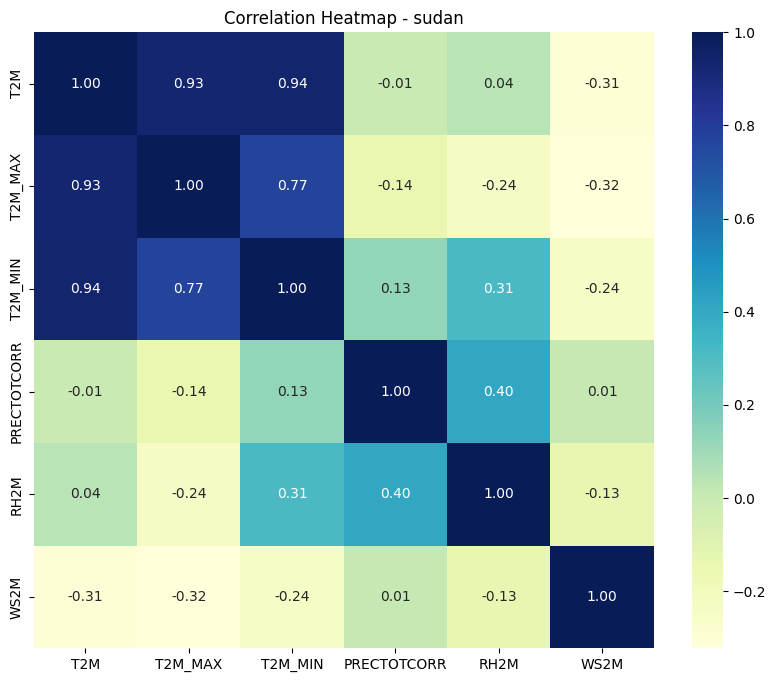

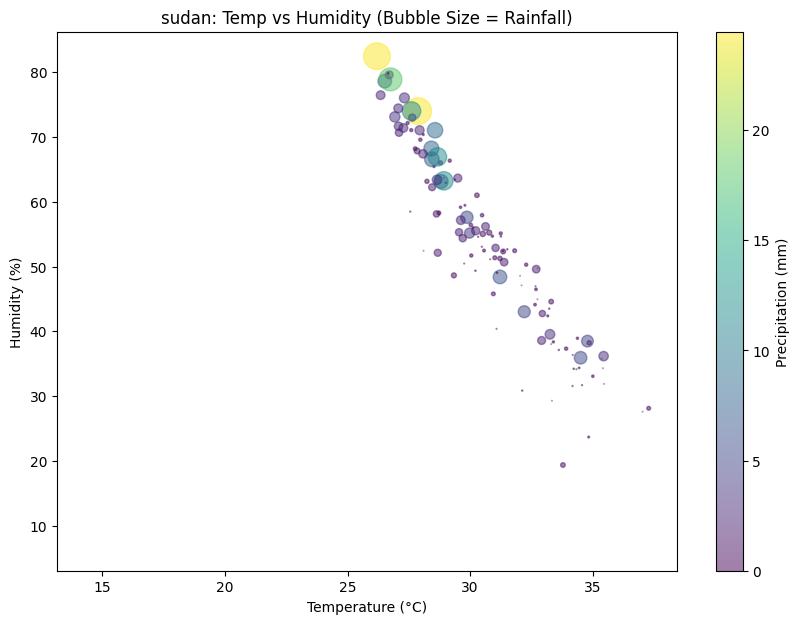

In [20]:
# 1. Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_to_check].corr(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation Heatmap - sudan')
plt.show()

# 2. Bubble Chart: Temp vs Humidity (Size = Rainfall)
sample_df = df.sample(500, random_state=42)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(sample_df['T2M'], sample_df['RH2M'], 
                      s=sample_df['PRECTOTCORR']*15, alpha=0.5, 
                      c=sample_df['PRECTOTCORR'], cmap='viridis')
plt.title('sudan: Temp vs Humidity (Bubble Size = Rainfall)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.colorbar(scatter, label='Precipitation (mm)')
plt.show()

# Sudan Climate Analysis: Negotiation-Grade Insights

### 1. What is changing? (Trend)
Sudan displays extreme baseline temperatures, with monthly averages frequently peaking between 34°C and 36°C. Unlike the bimodal rainfall of Kenya, Sudan’s precipitation is highly concentrated in very few months, with the majority of the year experiencing near-zero rainfall.

### 2. What did it cause? (Impact)
The correlation heatmap shows a near-perfect relationship between T2M and T2M_MAX (0.93). The bubble chart reveals a "desert signature": a steep linear decline where rising temperatures directly drive humidity down to 20%. The 82 detected outliers represent rare but intense heat and rain events that occur outside the normal desert cycle.

### 3. What does it demand? (Policy)
Sudan faces a unique "double-threat" of extreme heat stress and sudden flash flooding. We demand **COP32 support for 'Cooling as a Right' infrastructure** and **arid-land flood management**. The data shows that when rainfall does occur, it happens at high temperatures, which can lead to rapid evaporation—demanding **underground water storage solutions** to prevent loss.
